# Task 1B Training — Instacart LSTM Demand Forecasting

Trains the LSTM demand forecasting model and a linear regression baseline. Loads preprocessed sliding-window data from `task1b_preprocessing.ipynb` and produces trained models, evaluation metrics, forecast charts, and SHAP attribution charts.

In [1]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive so the notebook can read and write files stored there.
drive.mount('/content/drive')

# Update DRIVE_ROOT to match the project root location on your Google Drive.
DRIVE_ROOT      = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')
# Paths to preprocessed artefacts, model outputs, raw data, and the checkpoint file.
PREPROC_DIR     = DRIVE_ROOT / 'data' / 'Task 1B' / 'processed'
OUTPUT_DIR      = DRIVE_ROOT / 'data' / 'Task 1B' / 'models'
RAW_DIR         = DRIVE_ROOT / 'data' / 'Task 1' / 'raw' / 'InstaCart Dataset'
CHECKPOINT_PATH = OUTPUT_DIR / 'training_checkpoint.json'

# Create the model output directory if it does not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'DRIVE_ROOT  : {DRIVE_ROOT}')
print(f'PREPROC_DIR : {PREPROC_DIR}')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')
print('OUTPUT_DIR confirmed.')


Mounted at /content/drive
DRIVE_ROOT  : /content/drive/MyDrive/Advanced AI/advanced-ai
PREPROC_DIR : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/processed
OUTPUT_DIR  : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models
OUTPUT_DIR confirmed.


**Before running:** update `DRIVE_ROOT` in the cell above to match the path where the project folder lives on your Google Drive.

## Section 1 — Imports and Configuration

Imports all required libraries and defines configuration constants for the LSTM architecture, training schedule, and sliding-window parameters. All window/feature constants must match the values used in `task1b_preprocessing.ipynb`.

In [2]:
import os
import json
import datetime
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

RANDOM_SEED    = 42
# Window/feature constants must match task1b_preprocessing.ipynb exactly.
INPUT_WINDOW   = 90     # Must match preprocessing: 90 days input
OUTPUT_HORIZON = 7      # Must match preprocessing: 7 days output
N_FEATURES     = 3      # Must match preprocessing: count + sin_dow + cos_dow
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.10
TEST_RATIO     = 0.20

# LSTM architecture
LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 32
DROPOUT_1    = 0.3    # Higher dropout on first layer: raw input is noisy
DROPOUT_2    = 0.2    # Lower dropout on second layer: representation is compressed
DENSE_UNITS  = OUTPUT_HORIZON   # Output layer produces one value per forecast horizon day

# Training
LEARNING_RATE   = 0.001  # Adam default; well-established for LSTM forecasting
BATCH_SIZE      = 512    # Stable gradients on noisy time series data
MAX_EPOCHS      = 50     # Sufficient ceiling; early stopping prevents wasted computation
ES_PATIENCE     = 10     # Stop when val_loss has not improved for 10 consecutive epochs
CKPT_FREQ       = 5      # Save a mid-training checkpoint every N epochs

# Stride for sliding window construction
STRIDE = 1

# Seed both TensorFlow and NumPy for reproducible weight initialisation and shuffling.
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('RANDOM_SEED     :', RANDOM_SEED)
print('INPUT_WINDOW    :', INPUT_WINDOW)
print('OUTPUT_HORIZON  :', OUTPUT_HORIZON)
print('N_FEATURES      :', N_FEATURES)
print('TRAIN_RATIO     :', TRAIN_RATIO)
print('VAL_RATIO       :', VAL_RATIO)
print('TEST_RATIO      :', TEST_RATIO)
print('LSTM_UNITS_1    :', LSTM_UNITS_1)
print('LSTM_UNITS_2    :', LSTM_UNITS_2)
print('DROPOUT_1       :', DROPOUT_1)
print('DROPOUT_2       :', DROPOUT_2)
print('LEARNING_RATE   :', LEARNING_RATE)
print('BATCH_SIZE      :', BATCH_SIZE)
print('MAX_EPOCHS      :', MAX_EPOCHS)
print('ES_PATIENCE     :', ES_PATIENCE)
print('CKPT_FREQ       :', CKPT_FREQ)


RANDOM_SEED     : 42
INPUT_WINDOW    : 90
OUTPUT_HORIZON  : 7
N_FEATURES      : 3
TRAIN_RATIO     : 0.7
VAL_RATIO       : 0.1
TEST_RATIO      : 0.2
LSTM_UNITS_1    : 64
LSTM_UNITS_2    : 32
DROPOUT_1       : 0.3
DROPOUT_2       : 0.2
LEARNING_RATE   : 0.001
BATCH_SIZE      : 512
MAX_EPOCHS      : 50
ES_PATIENCE     : 10
CKPT_FREQ       : 5


## Section 2 — Checkpointing Logic

Defines checkpoint read/write functions used throughout the pipeline. Each completed stage is recorded so the notebook can resume from the last saved point after a session restart. Writes are atomic using a `.tmp` file rename.

In [ ]:
CHECKPOINT_STAGES = [
    'products_selected',
    'windows_built',
    'training_complete',
    'baseline_complete',
    'evaluation_complete',
]


def save_checkpoint(stage, payload=None):
    # Write stage and timestamp atomically to avoid a corrupt file on interrupted writes.
    data = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(),
    }
    if payload:
        data.update(payload)
    # Write to a .tmp file then rename; the rename is an atomic OS operation.
    tmp = str(CHECKPOINT_PATH) + '.tmp'
    with open(tmp, 'w', encoding='utf-8') as fh:
        json.dump(data, fh, indent=2)
    os.replace(tmp, CHECKPOINT_PATH)
    print(f'Checkpoint saved: stage={stage}')


def load_checkpoint():
    # Return the checkpoint payload dict, or an empty stage dict if no file exists.
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
            return json.load(fh)
    return {'stage': ''}


def stage_index(stage):
    # Return the integer position of a stage name in the ordered stages list.
    # 'mid_training' and empty strings are treated as -1 (before any named stage).
    if not stage or stage == 'mid_training':
        return -1
    try:
        return CHECKPOINT_STAGES.index(stage)
    except ValueError:
        return -1


def past_stage(current, stage):
    # True if current is strictly after stage.
    return stage_index(current) > stage_index(stage)


def reached_stage(current, stage):
    # True if current is at or after stage.
    return stage_index(current) >= stage_index(stage)


CKPT          = load_checkpoint()
CURRENT_STAGE = CKPT.get('stage', '')
if CURRENT_STAGE:
    print(f'Checkpoint found: stage={CURRENT_STAGE}')
    print('Completed sections will be skipped.')
else:
    print('No checkpoint found. Pipeline will run from the beginning.')


No checkpoint found. Pipeline will run from the beginning.


## Section 3 — Shared Pipeline Functions

All reusable logic is defined here so both the test run and the full pipeline call identical code. Functions cover data loading, window construction, LSTM model building, baseline fitting, evaluation, and chart generation.

In [ ]:
def load_preprocessed_data(preproc_dir):
    preproc_dir = Path(preproc_dir)
    # Load the list of product IDs that passed the minimum purchase threshold.
    with open(preproc_dir / 'qualifying_products.json', 'r', encoding='utf-8') as fh:
        qualifying_pids = json.load(fh)
    print(f'Qualifying products loaded : {len(qualifying_pids):,}')

    # Load pre-fitted MinMaxScalers, one per qualifying product.
    scaler_dict = joblib.load(preproc_dir / 'scalers.joblib')
    print(f'Scalers loaded             : {len(scaler_dict):,}')

    # Load the augmented daily order count table including seasonally augmented rows.
    augmented_df = pd.read_parquet(preproc_dir / 'daily_counts_augmented.parquet')
    augmented_df['date'] = pd.to_datetime(augmented_df['date'])
    print(f'Augmented daily counts     : {augmented_df.shape}')

    return qualifying_pids, scaler_dict, augmented_df


def select_all_products(qualifying_pids, augmented_df):
    """Return all qualifying product IDs for full-dataset training.

    No sampling or stratification is applied -- all products that passed
    the minimum purchase threshold in preprocessing are used. This ensures
    the global LSTM trains on the complete demand spectrum without any
    artificial selection bias.
    """
    pid_set = set(qualifying_pids)
    present = augmented_df['product_id'].unique()
    # Keep only products that are in both the qualifying list and the augmented table.
    selected = [pid for pid in qualifying_pids if pid in pid_set and pid in set(present)]
    print(f'Total products selected : {len(selected):,}  (all qualifying products)')
    return selected


def build_windows_for_products(selected_pids, augmented_df, scaler_dict,
                                input_window, output_horizon, stride,
                                train_ratio, val_ratio, random_seed):
    # Normalise each product series using its pre-fitted MinMaxScaler,
    # append day-of-week cyclical features, then split windows positionally.
    # Training windows are shuffled; val and test retain temporal order.
    # Returns six float32 arrays and product_window_counts dict.
    train_X_list, train_y_list = [], []
    val_X_list,   val_y_list   = [], []
    test_X_list,  test_y_list  = [], []
    pw_train, pw_val, pw_test  = {}, {}, {}

    grp = augmented_df.groupby('product_id')

    for pid in selected_pids:
        if pid not in grp.groups:
            continue
        # Extract the daily order count series for this product, sorted by date.
        series = (
            grp.get_group(pid)
            .set_index('date')
            .sort_index()['order_count']
        )
        n_days = len(series)
        # Skip products whose series is too short to form even one window.
        if n_days < input_window + output_horizon:
            continue

        scaler = scaler_dict.get(pid)
        if scaler is None:
            continue

        # Normalise demand to [0, 1] using the pre-fitted scaler; clip to guard
        # against rare values that fall outside the training range.
        norm_vals = np.clip(
            scaler.transform(series.values.reshape(-1, 1)).flatten(),
            0.0, 1.0,
        ).astype(np.float32)

        # Cyclical day-of-week encoding: maps each day to a point on the unit circle.
        dow     = series.index.dayofweek.values.astype(np.float32)
        sin_dow = np.sin(2 * np.pi * dow / 7).astype(np.float32)
        cos_dow = np.cos(2 * np.pi * dow / 7).astype(np.float32)
        # Stack into a (n_days, 3) feature array: [normalised_count, sin_dow, cos_dow].
        feat    = np.stack([norm_vals, sin_dow, cos_dow], axis=1)

        # Build sliding windows by stepping through the time axis with given stride.
        all_X, all_y = [], []
        for i in range(0, n_days - input_window - output_horizon + 1, stride):
            all_X.append(feat[i : i + input_window])
            all_y.append(norm_vals[i + input_window : i + input_window + output_horizon])

        if not all_X:
            continue

        all_X  = np.array(all_X, dtype=np.float32)
        all_y  = np.array(all_y, dtype=np.float32)
        n_win  = len(all_X)

        # Positional split: train first, then val, then test (temporal order preserved).
        n_train = int(n_win * train_ratio)
        n_val   = int(n_win * val_ratio)
        n_test  = n_win - n_train - n_val

        train_X_list.append(all_X[:n_train])
        train_y_list.append(all_y[:n_train])
        val_X_list.append(  all_X[n_train : n_train + n_val])
        val_y_list.append(  all_y[n_train : n_train + n_val])
        test_X_list.append( all_X[n_train + n_val :])
        test_y_list.append( all_y[n_train + n_val :])

        pw_train[pid] = n_train
        pw_val[pid]   = n_val
        pw_test[pid]  = n_test

    # Concatenate per-product lists into single arrays.
    X_train = np.concatenate(train_X_list, axis=0).astype(np.float32)
    y_train = np.concatenate(train_y_list, axis=0).astype(np.float32)
    X_val   = np.concatenate(val_X_list,   axis=0).astype(np.float32)
    y_val   = np.concatenate(val_y_list,   axis=0).astype(np.float32)
    X_test  = np.concatenate(test_X_list,  axis=0).astype(np.float32)
    y_test  = np.concatenate(test_y_list,  axis=0).astype(np.float32)

    # Shuffle training windows so the model does not see products in a fixed order.
    rng     = np.random.default_rng(random_seed)
    idx     = rng.permutation(len(X_train))
    X_train = X_train[idx]
    y_train = y_train[idx]

    product_window_counts = {'train': pw_train, 'val': pw_val, 'test': pw_test}

    total = len(X_train) + len(X_val) + len(X_test)
    print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
    print(f'X_val   : {X_val.shape}   y_val   : {y_val.shape}')
    print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
    print(f'Total windows : {total:,}')

    return X_train, y_train, X_val, y_val, X_test, y_test, product_window_counts


def build_lstm_model(input_window, n_features, lstm_units_1, lstm_units_2,
                     dropout_1, dropout_2, output_horizon, learning_rate):
    # Two stacked LSTM layers; dropout after each layer regularises the model.
    # A Dense output layer produces the multi-step forecast vector.
    inputs  = Input(shape=(input_window, n_features), name='input')
    # First LSTM layer: return_sequences=True passes the full sequence to the next layer.
    x       = LSTM(lstm_units_1, return_sequences=True, name='lstm_1')(inputs)
    x       = Dropout(dropout_1, name='dropout_1')(x)
    # Second LSTM layer: return_sequences=False collapses to a single context vector.
    x       = LSTM(lstm_units_2, return_sequences=False, name='lstm_2')(x)
    x       = Dropout(dropout_2, name='dropout_2')(x)
    # Dense output: one unit per forecast horizon day.
    outputs = Dense(output_horizon, name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='lstm_demand_forecast')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    model.summary()
    return model


def build_baseline_model(X_train, y_train):
    """Fit a Multi-Output Linear Regression baseline on all training windows.

    The baseline is trained on exactly the same data as the LSTM so that
    the comparison is fair. The input windows are flattened from
    (n_windows, input_window, n_features) to (n_windows, input_window * n_features)
    since Linear Regression cannot process 3-D input directly.
    """
    n_total = len(X_train)
    # Flatten 3-D windows to 2-D feature vectors for linear regression.
    X_fit   = X_train.reshape(n_total, -1)
    y_fit   = y_train
    print(f'Baseline fitted on {n_total:,} training windows (same data as LSTM).')
    baseline = MultiOutputRegressor(LinearRegression())
    baseline.fit(X_fit, y_fit)
    return baseline


def _inverse_transform_by_product(preds_norm, labels_norm, scaler_dict,
                                   selected_pids, product_window_counts_test,
                                   n_products_eval):
    # Inverse transform predictions and labels for up to n_products_eval products.
    # Test windows are ordered by product following selected_pids order.
    per_mae, per_rmse = [], []
    offset = 0

    for pid in selected_pids:
        count = product_window_counts_test.get(pid, 0)
        if count == 0:
            continue
        if len(per_mae) < n_products_eval:
            scaler = scaler_dict.get(pid)
            if scaler is not None:
                # Slice this product's test predictions and labels.
                pid_pred  = preds_norm[offset : offset + count]
                pid_label = labels_norm[offset : offset + count]
                # Inverse transform back to original demand units.
                pred_inv  = scaler.inverse_transform(
                    pid_pred.reshape(-1, 1)
                ).reshape(pid_pred.shape)
                label_inv = scaler.inverse_transform(
                    pid_label.reshape(-1, 1)
                ).reshape(pid_label.shape)
                per_mae.append(
                    mean_absolute_error(label_inv.flatten(), pred_inv.flatten())
                )
                per_rmse.append(
                    float(np.sqrt(mean_squared_error(label_inv.flatten(), pred_inv.flatten())))
                )
        offset += count

    return per_mae, per_rmse


def evaluate_model(model, X_test, y_test, scaler_dict, selected_pids,
                   product_window_counts, n_products_eval=100):
    # Evaluate LSTM on test set. Reports normalised and inverse-transformed metrics.
    preds_norm = model.predict(X_test, verbose=0).astype(np.float32)

    # Normalised metrics measure error in the [0, 1] scaled space.
    norm_mae  = float(mean_absolute_error(y_test.flatten(), preds_norm.flatten()))
    norm_rmse = float(np.sqrt(mean_squared_error(y_test.flatten(), preds_norm.flatten())))

    # Inverse-transformed metrics measure error in the original daily order count units.
    per_mae, per_rmse = _inverse_transform_by_product(
        preds_norm, y_test, scaler_dict, selected_pids,
        product_window_counts['test'], n_products_eval,
    )

    inv_mae  = float(np.mean(per_mae))  if per_mae  else float('nan')
    inv_rmse = float(np.mean(per_rmse)) if per_rmse else float('nan')

    print('LSTM evaluation results:')
    print(f'  Normalised MAE          : {norm_mae:.6f}')
    print(f'  Normalised RMSE         : {norm_rmse:.6f}')
    print(f'  Inverse-transformed MAE : {inv_mae:.4f}  (avg over {len(per_mae)} products)')
    print(f'  Inverse-transformed RMSE: {inv_rmse:.4f}')

    return {
        'normalised_mae' : norm_mae,
        'normalised_rmse': norm_rmse,
        'inv_mae'        : inv_mae,
        'inv_rmse'       : inv_rmse,
    }


def evaluate_baseline(baseline_model, X_test, y_test, scaler_dict, selected_pids,
                       product_window_counts, input_window, n_features,
                       n_products_eval=100):
    # Evaluate baseline using identical logic to evaluate_model.
    # Flatten 3-D windows for the linear model before predicting.
    X_flat     = X_test.reshape(len(X_test), input_window * n_features)
    preds_norm = baseline_model.predict(X_flat).astype(np.float32)

    norm_mae  = float(mean_absolute_error(y_test.flatten(), preds_norm.flatten()))
    norm_rmse = float(np.sqrt(mean_squared_error(y_test.flatten(), preds_norm.flatten())))

    per_mae, per_rmse = _inverse_transform_by_product(
        preds_norm, y_test, scaler_dict, selected_pids,
        product_window_counts['test'], n_products_eval,
    )

    inv_mae  = float(np.mean(per_mae))  if per_mae  else float('nan')
    inv_rmse = float(np.mean(per_rmse)) if per_rmse else float('nan')

    print('Baseline evaluation results:')
    print(f'  Normalised MAE          : {norm_mae:.6f}')
    print(f'  Normalised RMSE         : {norm_rmse:.6f}')
    print(f'  Inverse-transformed MAE : {inv_mae:.4f}  (avg over {len(per_mae)} products)')
    print(f'  Inverse-transformed RMSE: {inv_rmse:.4f}')

    return {
        'normalised_mae' : norm_mae,
        'normalised_rmse': norm_rmse,
        'inv_mae'        : inv_mae,
        'inv_rmse'       : inv_rmse,
    }


def generate_forecast_charts(model, scaler_dict, augmented_df, selected_pids,
                              output_dir, input_window, output_horizon, n_features,
                              n_charts=10):
    # Generate forecast charts for the n_charts longest-series products.
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    grp = augmented_df.groupby('product_id')

    # Sort products by series length and take the n_charts longest.
    series_lengths = [
        (pid, len(grp.get_group(pid)))
        for pid in selected_pids
        if pid in grp.groups
    ]
    series_lengths.sort(key=lambda x: x[1], reverse=True)
    chart_pids = [pid for pid, _ in series_lengths[:n_charts]]

    print(f'Generating forecast charts for {len(chart_pids)} products:')
    saved_paths = []

    for pid in chart_pids:
        series     = grp.get_group(pid).set_index('date').sort_index()['order_count']
        series_len = len(series)
        print(f'  product_id={pid}  series_length={series_len}')

        scaler = scaler_dict.get(pid)
        if scaler is None or series_len < input_window:
            continue

        # Use the last input_window days as context for the forecast.
        context_raw  = series.values[-input_window:].reshape(-1, 1)
        context_norm = np.clip(scaler.transform(context_raw).flatten(), 0.0, 1.0)

        # Build cyclical day-of-week features for the context window.
        dow     = series.index[-input_window:].dayofweek.values.astype(np.float32)
        sin_dow = np.sin(2 * np.pi * dow / 7).astype(np.float32)
        cos_dow = np.cos(2 * np.pi * dow / 7).astype(np.float32)
        # Stack into model input shape: (1, input_window, n_features).
        feat    = np.stack(
            [context_norm.astype(np.float32), sin_dow, cos_dow], axis=1
        )[np.newaxis, ...]

        # Predict the next output_horizon days and inverse transform to original units.
        pred_norm   = model.predict(feat, verbose=0)[0]
        context_inv = scaler.inverse_transform(context_norm.reshape(-1, 1)).flatten()
        pred_inv    = scaler.inverse_transform(pred_norm.reshape(-1, 1)).flatten()

        # x-axis: negative indices for history, non-negative for forecast.
        hist_x = list(range(-input_window, 0))
        fore_x = list(range(0, output_horizon))

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(hist_x, context_inv, color='steelblue', linewidth=1.2,
                label='historical')
        ax.plot(fore_x, pred_inv, color='darkorange', linewidth=1.5,
                linestyle='--', marker='o', markersize=4, label='forecast')
        ax.axvline(x=0, color='grey', linestyle='--', linewidth=0.8,
                   label='forecast boundary')
        ax.set_title(f'Demand forecast -- product {pid}')
        ax.set_xlabel('relative day (0 = forecast start)')
        ax.set_ylabel('daily order count')
        ax.legend()
        plt.tight_layout()

        out_path = output_dir / f'forecast_{pid}.png'
        fig.savefig(out_path, dpi=100)
        plt.close(fig)
        saved_paths.append(out_path)

    print(f'Saved {len(saved_paths)} forecast charts to {output_dir}')
    return chart_pids, saved_paths


def generate_shap_chart(model, X_sample, product_name, output_dir,
                         input_window, output_horizon, pid):
    # Perturbation-based attribution: zero each day count feature in turn,
    # measure change in mean predicted demand, normalise importances to sum 1.
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Baseline prediction with the unmodified input.
    base_pred   = model.predict(X_sample, verbose=0)[0]
    base_scalar = float(np.mean(base_pred))

    importances = np.zeros(input_window, dtype=np.float32)
    for i in range(input_window):
        perturbed      = X_sample.copy()
        # Zero only the demand count feature (index 0); day-of-week features are unchanged.
        perturbed[0, i, 0] = 0.0
        pert_pred      = model.predict(perturbed, verbose=0)[0]
        # Importance = change in mean forecast caused by removing this day's demand signal.
        importances[i] = abs(base_scalar - float(np.mean(pert_pred)))

    # Normalise so all importances sum to 1 for a comparable scale across products.
    importance_sum = importances.sum()
    if importance_sum > 0:
        importances /= importance_sum

    fig, ax = plt.subplots(figsize=(8, max(4, input_window // 10)))
    ax.barh(np.arange(input_window), importances,
            color='steelblue', edgecolor='none')
    ax.set_title(f'Demand forecast attribution -- {product_name}')
    ax.set_xlabel('normalised importance')
    ax.set_ylabel('input day (0 = oldest)')
    ax.invert_yaxis()
    plt.tight_layout()

    out_path = output_dir / f'shap_{pid}.png'
    fig.savefig(out_path, dpi=100)
    plt.close(fig)

    return importances


print('Shared pipeline functions defined.')


Shared pipeline functions defined.


## Section 4 — Mid-Training Checkpoint Callback

Training on the full product catalogue can take hours. This Keras callback saves the model weights and current metrics to disk every `CKPT_FREQ` epochs so that a crashed session can resume rather than restart from scratch.

In [ ]:
class EpochCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_path, ckpt_freq, output_dir):
        super().__init__()
        self.checkpoint_path = checkpoint_path
        self.ckpt_freq       = ckpt_freq
        self.output_dir      = output_dir

    def on_epoch_end(self, epoch, logs=None):
        # Save a mid-training checkpoint every ckpt_freq epochs.
        if (epoch + 1) % self.ckpt_freq == 0:
            mid_ckpt = {
                'stage'       : 'mid_training',
                'epoch'       : epoch + 1,
                'val_loss'    : float(logs.get('val_loss', float('inf'))),
                'val_mae'     : float(logs.get('val_mae', float('inf'))),
                'timestamp'   : datetime.datetime.now().isoformat(),
                # Path used to reload weights when resuming a crashed session.
                'weights_path': str(self.output_dir / 'lstm_mid_training.weights.h5'),
            }
            # Save current model weights alongside the checkpoint payload.
            self.model.save_weights(str(self.output_dir / 'lstm_mid_training.weights.h5'))
            # Atomic write: write to .tmp then rename to avoid partial reads.
            tmp = str(self.checkpoint_path) + '.tmp'
            with open(tmp, 'w', encoding='utf-8') as fh:
                json.dump(mid_ckpt, fh, indent=2)
            os.replace(tmp, self.checkpoint_path)
            print(f'  Mid-training checkpoint saved at epoch {epoch + 1}'
                  f'  val_loss={logs.get("val_loss", float("inf")):.6f}')


print('EpochCheckpointCallback defined.')


EpochCheckpointCallback defined.


## Section 5 — Optional Test Run

Set `RUN_TEST = True` to run the complete pipeline on 30 sampled products. All temporary files are deleted on completion and no checkpoint is written to permanent storage.

In [ ]:
RUN_TEST = False

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    import shutil
    print('=' * 60)
    print('TRAINING PIPELINE - TEST RUN')
    print('=' * 60)
    print()

    # Step 1: Load data.
    print('Step 1 - Load preprocessed data')
    t_qualifying_pids, t_scaler_dict, t_augmented_df = load_preprocessed_data(PREPROC_DIR)
    print(f'Qualifying products: {len(t_qualifying_pids):,}')
    print()

    # Step 2: Select 30 products from the full qualifying set for the test run.
    # The test run uses a small fixed subset to verify the pipeline quickly.
    # The full pipeline uses all qualifying products via select_all_products.
    print('Step 2 - Select 30 products (test subset)')
    import random as _rnd
    _rnd.seed(RANDOM_SEED)
    t_selected_pids = _rnd.sample(t_qualifying_pids, min(30, len(t_qualifying_pids)))
    print(f'Selected {len(t_selected_pids)} products for test run')
    print()

    # Step 3: Build windows.
    print('Step 3 - Build sliding windows')
    (t_X_train, t_y_train, t_X_val, t_y_val, t_X_test, t_y_test,
     t_product_window_counts) = build_windows_for_products(
        t_selected_pids, t_augmented_df, t_scaler_dict,
        INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
        TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
    )
    # Verify window shape matches the expected INPUT_WINDOW and N_FEATURES constants.
    assert not np.any(np.isnan(t_X_train)), 'NaNs found in X_train'
    assert not np.any(np.isnan(t_y_train)), 'NaNs found in y_train'
    assert t_X_train.shape[1] == INPUT_WINDOW, \
        f'Expected INPUT_WINDOW={INPUT_WINDOW}, got {t_X_train.shape[1]}'
    assert t_X_train.shape[2] == N_FEATURES, \
        f'Expected N_FEATURES={N_FEATURES}, got {t_X_train.shape[2]}'
    print('Shape assertions passed.')
    print()

    # Step 4: Build LSTM model.
    print('Step 4 - Build LSTM model')
    t_model = build_lstm_model(
        INPUT_WINDOW, N_FEATURES, LSTM_UNITS_1, LSTM_UNITS_2,
        DROPOUT_1, DROPOUT_2, OUTPUT_HORIZON, LEARNING_RATE,
    )
    print()

    # Step 5: Fit baseline on all training windows (same data as LSTM).
    print('Step 5 - Fit baseline model')
    t_baseline = build_baseline_model(t_X_train, t_y_train)
    print()

    # Step 6: Train LSTM (max 6 epochs).
    print('Step 6 - Train LSTM (6 epochs max)')
    t_test_model_path = OUTPUT_DIR / 'lstm_test_best.keras'
    t_callbacks = [
        # Stop early if val_loss does not improve for 3 consecutive epochs.
        EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=1,
        ),
        # Save the best model to a test-specific path, not the production path.
        ModelCheckpoint(
            filepath=str(t_test_model_path),
            monitor='val_loss', save_best_only=True, verbose=1,
        ),
        # Save a mid-training checkpoint every 2 epochs for resume verification.
        EpochCheckpointCallback(CHECKPOINT_PATH, ckpt_freq=2, output_dir=OUTPUT_DIR),
    ]
    t_history = t_model.fit(
        t_X_train, t_y_train,
        validation_data=(t_X_val, t_y_val),
        epochs=6,
        batch_size=BATCH_SIZE,
        callbacks=t_callbacks,
        verbose=1,
    )

    # Verify the mid-training checkpoint was written and has the expected structure.
    assert CHECKPOINT_PATH.exists(), 'Mid-training checkpoint file not found.'
    with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
        t_mid_ckpt = json.load(fh)
    assert 'epoch' in t_mid_ckpt,    'Mid-training checkpoint missing epoch key.'
    assert 'val_loss' in t_mid_ckpt, 'Mid-training checkpoint missing val_loss key.'
    print('Mid-training checkpoint contents:')
    print(json.dumps(t_mid_ckpt, indent=2))

    # Clean up test model files so they do not interfere with the full pipeline.
    if t_test_model_path.exists():
        t_test_model_path.unlink()
    t_weights_path = OUTPUT_DIR / 'lstm_mid_training.weights.h5'
    if t_weights_path.exists():
        t_weights_path.unlink()
    if CHECKPOINT_PATH.exists():
        CHECKPOINT_PATH.unlink()
    print('Test model files deleted.')
    print()

    # Step 7: Evaluate LSTM.
    print('Step 7 - Evaluate LSTM')
    t_lstm_metrics = evaluate_model(
        t_model, t_X_test, t_y_test, t_scaler_dict,
        t_selected_pids, t_product_window_counts, n_products_eval=10,
    )
    print()

    # Step 8: Evaluate baseline.
    print('Step 8 - Evaluate baseline')
    t_baseline_metrics = evaluate_baseline(
        t_baseline, t_X_test, t_y_test, t_scaler_dict,
        t_selected_pids, t_product_window_counts,
        INPUT_WINDOW, N_FEATURES, n_products_eval=10,
    )
    print()

    # Step 9: Generate forecast charts (3 charts).
    print('Step 9 - Generate forecast charts')
    t_charts_dir = OUTPUT_DIR / 'test_charts'
    t_chart_pids, t_chart_paths = generate_forecast_charts(
        t_model, t_scaler_dict, t_augmented_df, t_selected_pids,
        t_charts_dir, INPUT_WINDOW, OUTPUT_HORIZON, N_FEATURES, n_charts=3,
    )
    # Confirm the expected number of PNG files was written.
    generated_pngs = list(t_charts_dir.glob('forecast_*.png'))
    assert len(generated_pngs) == len(t_chart_pids), \
        f'Expected {len(t_chart_pids)} forecast PNGs, found {len(generated_pngs)}.'
    shutil.rmtree(t_charts_dir)
    print('Test charts deleted.')
    print()

    # Step 10: Generate SHAP chart.
    print('Step 10 - Generate SHAP chart')
    t_shap_dir = OUTPUT_DIR / 'test_shap'
    t_shap_dir.mkdir(parents=True, exist_ok=True)
    # Find the first product that has at least one test window.
    t_shap_pid = None
    for _pid in t_selected_pids:
        if t_product_window_counts['test'].get(_pid, 0) > 0:
            t_shap_pid = _pid
            break
    if t_shap_pid is not None:
        t_shap_X = t_X_test[:1]
        generate_shap_chart(
            t_model, t_shap_X, str(t_shap_pid),
            t_shap_dir, INPUT_WINDOW, OUTPUT_HORIZON, t_shap_pid,
        )
        t_shap_file = t_shap_dir / f'shap_{t_shap_pid}.png'
        assert t_shap_file.exists(), 'SHAP chart not saved.'
    shutil.rmtree(t_shap_dir)
    print('SHAP test directory deleted.')
    print()

    # Step 11: Verify and clean up.
    print('Step 11 - Verify and clean up')
    # The permanent checkpoint must not exist after the test run.
    assert not CHECKPOINT_PATH.exists(), \
        'Permanent checkpoint should not exist after test run.'
    print(
        'Test run complete. All temporary files deleted.'
        ' No checkpoint written to permanent storage.'
        ' Safe to proceed with the full pipeline.'
    )


TRAINING PIPELINE - TEST RUN

Step 1 - Load preprocessed data
Qualifying products loaded : 28,552
Scalers loaded             : 28,552
Augmented daily counts     : (10907296, 3)
Qualifying products: 28,552

Step 2 - Select 30 products (test subset)
Selected 30 products for test run

Step 3 - Build sliding windows
X_train : (5018, 90, 3)   y_train : (5018, 7)
X_val   : (702, 90, 3)   y_val   : (702, 7)
X_test  : (1468, 90, 3)   y_test  : (1468, 7)
Total windows : 7,188
Shape assertions passed.

Step 4 - Build LSTM model


Model: "lstm_demand_forecast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 90, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,055 (117.40 KB)

 Trainable params: 30,055 (117.40 KB)

 Non-trainable params: 0 (0.00 B)


Step 5 - Fit baseline model
Baseline fitted on 5,018 training windows (same data as LSTM).

Step 6 - Train LSTM (6 epochs max)
Epoch 1/6
 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1198 - mae: 0.2280
Epoch 1: val_loss improved from None to 0.05603, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_test_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_test_best.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0981 - mae: 0.2103 - val_loss: 0.0560 - val_mae: 0.1786
Epoch 2/6
 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0747 - mae: 0.2109
Epoch 2: val_loss improved from 0.05603 to 0.05056, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_test_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_test_best.keras
  Mid-training checkpoint saved at epoch 2  val_loss=

## Section 6 — Load Preprocessed Data

Loads qualifying product IDs, fitted scalers, and the augmented daily counts table produced by `task1b_preprocessing.ipynb`.

In [ ]:
if past_stage(CURRENT_STAGE, 'products_selected'):
    print(f'Section 6 skipped: already past products_selected (stage={CURRENT_STAGE}).')
else:
    # Load qualifying products, fitted scalers, and the augmented daily counts table.
    qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)


Qualifying products loaded : 28,552
Scalers loaded             : 28,552
Augmented daily counts     : (10907296, 3)


## Section 7 — Select Products and Build Windows

All qualifying products are selected for training. Normalised sliding windows are constructed for each product’s time series and split positionally into train, validation, and test sets. Training windows are shuffled; validation and test retain temporal order.

In [ ]:
if past_stage(CURRENT_STAGE, 'windows_built'):
    print(f'Section 7 skipped: already past windows_built (stage={CURRENT_STAGE}).')
else:
    # Rebuild mode: windows were built but session crashed before training started.
    if reached_stage(CURRENT_STAGE, 'windows_built'):
        print('Detected windows_built checkpoint. Rebuilding window arrays from saved files.')
        # Reload the saved product list rather than re-running product selection.
        with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
            selected_pids = json.load(fh)
        if 'augmented_df' not in dir():
            qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)
        (X_train, y_train, X_val, y_val, X_test, y_test,
         product_window_counts) = build_windows_for_products(
            selected_pids, augmented_df, scaler_dict,
            INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
            TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
        )
        print('Window arrays rebuilt from saved product list.')
    else:
        # Fresh run: select products then build windows.
        if 'qualifying_pids' not in dir():
            qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)

        print('Selecting products...')
        selected_pids = select_all_products(qualifying_pids, augmented_df)
        # Persist the product list so it can be reloaded on resume.
        with open(OUTPUT_DIR / 'selected_products.json', 'w', encoding='utf-8') as fh:
            json.dump([int(p) for p in selected_pids], fh)
        print(f'Saved selected_products.json ({len(selected_pids)} products)')

        save_checkpoint('products_selected')
        CURRENT_STAGE = 'products_selected'

        print()
        print('Building sliding windows...')
        (X_train, y_train, X_val, y_val, X_test, y_test,
         product_window_counts) = build_windows_for_products(
            selected_pids, augmented_df, scaler_dict,
            INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
            TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
        )

        # Serialise product_window_counts: keys must be strings for JSON.
        pwc_json = {
            split: {str(pid): cnt for pid, cnt in split_dict.items()}
            for split, split_dict in product_window_counts.items()
        }
        with open(OUTPUT_DIR / 'product_window_counts.json', 'w', encoding='utf-8') as fh:
            json.dump(pwc_json, fh)
        print('Saved product_window_counts.json')

        save_checkpoint('windows_built')
        CURRENT_STAGE = 'windows_built'

    print()
    print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
    print(f'X_val   : {X_val.shape}   y_val   : {y_val.shape}')
    print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
    print(f'Total windows : {len(X_train) + len(X_val) + len(X_test):,}')


Selecting products...
Total products selected : 28,552  (all qualifying products)
Saved selected_products.json (28552 products)
Checkpoint saved: stage=products_selected

Building sliding windows...
X_train : (4764878, 90, 3)   y_train : (4764878, 7)
X_val   : (669939, 90, 3)   y_val   : (669939, 7)
X_test  : (1391110, 90, 3)   y_test  : (1391110, 7)
Total windows : 6,825,927
Saved product_window_counts.json
Checkpoint saved: stage=windows_built

X_train : (4764878, 90, 3)   y_train : (4764878, 7)
X_val   : (669939, 90, 3)   y_val   : (669939, 7)
X_test  : (1391110, 90, 3)   y_test  : (1391110, 7)
Total windows : 6,825,927


## Section 8 — Build and Train LSTM Model

Builds a two-layer stacked LSTM with dropout regularisation and trains it on the sliding windows. A mid-training checkpoint is saved every `CKPT_FREQ` epochs. If a mid-training checkpoint exists, training resumes from the saved epoch and weights.

In [ ]:
if past_stage(CURRENT_STAGE, 'training_complete'):
    print(f'Section 8 skipped: training already complete (stage={CURRENT_STAGE}).')
else:
    # Ensure window arrays are in memory.
    if 'X_train' not in dir():
        if 'selected_pids' not in dir():
            with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
                selected_pids = json.load(fh)
        if 'augmented_df' not in dir():
            qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)
        (X_train, y_train, X_val, y_val, X_test, y_test,
         product_window_counts) = build_windows_for_products(
            selected_pids, augmented_df, scaler_dict,
            INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
            TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
        )

    # Detect mid-training checkpoint for resume.
    mid_ckpt_data = CKPT if CURRENT_STAGE == 'mid_training' else None
    if mid_ckpt_data is not None:
        print(f'Resuming from mid-training checkpoint: epoch={mid_ckpt_data["epoch"]}')

    model = build_lstm_model(
        INPUT_WINDOW, N_FEATURES, LSTM_UNITS_1, LSTM_UNITS_2,
        DROPOUT_1, DROPOUT_2, OUTPUT_HORIZON, LEARNING_RATE,
    )

    initial_epoch = 0
    if mid_ckpt_data is not None:
        weights_path = mid_ckpt_data.get('weights_path', '')
        if weights_path and Path(weights_path).exists():
            # Reload weights saved by EpochCheckpointCallback to continue from mid-run.
            model.load_weights(weights_path)
            initial_epoch = int(mid_ckpt_data['epoch'])
            print(f'Weights loaded from {weights_path}. Resuming from epoch {initial_epoch}.')
        else:
            print('Warning: mid-training weights file not found. Training from epoch 0.')

    callbacks = [
        # Stop training if val_loss does not improve for ES_PATIENCE epochs.
        EarlyStopping(
            monitor='val_loss', patience=ES_PATIENCE,
            restore_best_weights=True, verbose=1,
        ),
        # Save the best model by val_loss to disk throughout training.
        ModelCheckpoint(
            filepath=str(OUTPUT_DIR / 'lstm_best.keras'),
            monitor='val_loss', save_best_only=True, verbose=1,
        ),
        # Write a mid-training checkpoint every CKPT_FREQ epochs for resume support.
        EpochCheckpointCallback(CHECKPOINT_PATH, CKPT_FREQ, OUTPUT_DIR),
    ]

    print()
    print(f'Training LSTM: initial_epoch={initial_epoch}  max_epochs={MAX_EPOCHS}')
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        initial_epoch=initial_epoch,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # Save the final model (all epochs) alongside the best checkpoint.
    model.save(str(OUTPUT_DIR / 'lstm_forecast.keras'))
    print('Final model saved: lstm_forecast.keras')

    # Convert numpy float32 history values to native Python floats for JSON serialisation.
    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(OUTPUT_DIR / 'training_history.json', 'w', encoding='utf-8') as fh:
        json.dump(hist_dict, fh, indent=2)
    print('Training history saved: training_history.json')

    best_val_loss  = float(min(history.history['val_loss']))
    best_val_mae   = float(min(history.history.get('val_mae', [float('nan')])))
    epochs_trained = len(history.history['val_loss'])
    print(f'Epochs trained : {epochs_trained}')
    print(f'Best val_loss  : {best_val_loss:.6f}')
    print(f'Best val_mae   : {best_val_mae:.6f}')

    save_checkpoint('training_complete', payload={
        'best_val_loss' : best_val_loss,
        'best_val_mae'  : best_val_mae,
        'epochs_trained': epochs_trained,
        'model_path'    : str(OUTPUT_DIR / 'lstm_best.keras'),
    })
    CURRENT_STAGE = 'training_complete'


Model: "lstm_demand_forecast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 90, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,055 (117.40 KB)

 Trainable params: 30,055 (117.40 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM: initial_epoch=0  max_epochs=50
Epoch 1/50
9306/9307 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0655 - mae: 0.1836
Epoch 1: val_loss improved from None to 0.04666, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_best.keras
9307/9307 ━━━━━━━━━━━━━━━━━━━━ 107s 11ms/step - loss: 0.0648 - mae: 0.1826 - val_loss: 0.0467 - val_mae: 0.1422
Epoch 2/50
9306/9307 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0644 - mae: 0.1820
Epoch 2: val_loss improved from 0.04666 to 0.04663, saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/lstm_best.keras
9307/9307 ━━━━━━━━━━━━━━━━━━━━ 104s 11ms/step - loss: 0.0644 - mae: 0.1820 - val_loss: 0.0466 - val_mae: 0.1443
Epoch 3/50
9305/9307 ━━━━━

## Section 9 — Fit Baseline Model

Fits a multi-output linear regression baseline on the same training windows used for the LSTM. Input windows are flattened to a 2-D array before fitting, since linear regression cannot process 3-D sequences.

In [ ]:
if past_stage(CURRENT_STAGE, 'baseline_complete'):
    print(f'Section 9 skipped: baseline already fitted (stage={CURRENT_STAGE}).')
else:
    # Ensure training windows are in memory before fitting the baseline.
    if 'X_train' not in dir():
        if 'selected_pids' not in dir():
            with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
                selected_pids = json.load(fh)
        if 'augmented_df' not in dir():
            qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)
        (X_train, y_train, X_val, y_val, X_test, y_test,
         product_window_counts) = build_windows_for_products(
            selected_pids, augmented_df, scaler_dict,
            INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
            TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
        )

    baseline_model = build_baseline_model(X_train, y_train)
    # Persist the fitted baseline for evaluation in Section 10.
    joblib.dump(baseline_model, OUTPUT_DIR / 'baseline_model.joblib')
    print('Saved: baseline_model.joblib')

    save_checkpoint('baseline_complete')
    CURRENT_STAGE = 'baseline_complete'


Baseline fitted on 4,764,878 training windows (same data as LSTM).
Saved: baseline_model.joblib
Checkpoint saved: stage=baseline_complete


## Section 10 — Evaluate Both Models

Evaluates the LSTM and the baseline on the held-out test windows. Both normalised and inverse-transformed MAE and RMSE are reported. Results are saved to `evaluation_results.json`.

In [ ]:
if past_stage(CURRENT_STAGE, 'evaluation_complete'):
    print(f'Section 10 skipped: evaluation already complete (stage={CURRENT_STAGE}).')
else:
    # Load the best LSTM model and the fitted baseline from disk.
    model          = tf.keras.models.load_model(str(OUTPUT_DIR / 'lstm_best.keras'))
    baseline_model = joblib.load(OUTPUT_DIR / 'baseline_model.joblib')
    print('Models loaded.')

    # Ensure test windows are in memory.
    if 'X_test' not in dir():
        if 'selected_pids' not in dir():
            with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
                selected_pids = json.load(fh)
        if 'augmented_df' not in dir():
            qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)
        (X_train, y_train, X_val, y_val, X_test, y_test,
         product_window_counts) = build_windows_for_products(
            selected_pids, augmented_df, scaler_dict,
            INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
            TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
        )

    print()
    lstm_metrics = evaluate_model(
        model, X_test, y_test, scaler_dict, selected_pids, product_window_counts,
    )
    print()
    baseline_metrics = evaluate_baseline(
        baseline_model, X_test, y_test, scaler_dict, selected_pids,
        product_window_counts, INPUT_WINDOW, N_FEATURES,
    )

    # Bundle both sets of metrics and save for downstream use.
    eval_results = {'lstm': lstm_metrics, 'baseline': baseline_metrics}
    with open(OUTPUT_DIR / 'evaluation_results.json', 'w', encoding='utf-8') as fh:
        json.dump(eval_results, fh, indent=2)
    print()
    print('Evaluation results saved: evaluation_results.json')

    print()
    print('Comparison summary:')
    print(f'  {"Metric":<30} {"LSTM":>12} {"Baseline":>12}')
    print(f'  {"-" * 30} {"-" * 12} {"-" * 12}')
    for key in ('normalised_mae', 'normalised_rmse', 'inv_mae', 'inv_rmse'):
        label = key.replace('_', ' ')
        print(f'  {label:<30} {lstm_metrics[key]:>12.6f} {baseline_metrics[key]:>12.6f}')

    save_checkpoint('evaluation_complete')
    CURRENT_STAGE = 'evaluation_complete'


Models loaded.

LSTM evaluation results:
  Normalised MAE          : 0.121200
  Normalised RMSE         : 0.191692
  Inverse-transformed MAE : 0.4990  (avg over 100 products)
  Inverse-transformed RMSE: 0.6294

Baseline evaluation results:
  Normalised MAE          : 0.196435
  Normalised RMSE         : 0.227820
  Inverse-transformed MAE : 0.8702  (avg over 100 products)
  Inverse-transformed RMSE: 0.9617

Evaluation results saved: evaluation_results.json

Comparison summary:
  Metric                                 LSTM     Baseline
  ------------------------------ ------------ ------------
  normalised mae                     0.121200     0.196435
  normalised rmse                    0.191692     0.227820
  inv mae                            0.498959     0.870239
  inv rmse                           0.629415     0.961653
Checkpoint saved: stage=evaluation_complete


## Section 11 — Generate Forecast and SHAP Charts

Produces a demand forecast chart for each of the 10 longest-series products, and a perturbation-based SHAP attribution chart for each. Charts are saved to `OUTPUT_DIR/charts/`.

In [ ]:
# Always runs -- charts are fast to regenerate.
if 'model' not in dir():
    model = tf.keras.models.load_model(str(OUTPUT_DIR / 'lstm_best.keras'))
    print('Model loaded.')

if 'X_test' not in dir():
    if 'selected_pids' not in dir():
        with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
            selected_pids = json.load(fh)
    if 'augmented_df' not in dir():
        qualifying_pids, scaler_dict, augmented_df = load_preprocessed_data(PREPROC_DIR)
    (X_train, y_train, X_val, y_val, X_test, y_test,
     product_window_counts) = build_windows_for_products(
        selected_pids, augmented_df, scaler_dict,
        INPUT_WINDOW, OUTPUT_HORIZON, STRIDE,
        TRAIN_RATIO, VAL_RATIO, RANDOM_SEED,
    )

charts_dir = OUTPUT_DIR / 'charts'
print('Generating forecast charts...')
chart_pids, chart_paths = generate_forecast_charts(
    model, scaler_dict, augmented_df, selected_pids,
    charts_dir, INPUT_WINDOW, OUTPUT_HORIZON, N_FEATURES, n_charts=10,
)

print()
print('Generating SHAP attribution charts...')

# Attempt to load a product name lookup; silently skip if the file is absent.
pid_to_name = {}
try:
    _fp = pd.read_parquet(PREPROC_DIR / 'filtered_products_1b.parquet')
    pid_to_name = dict(zip(_fp['product_id'], _fp['product_name']))
except Exception:
    pass

# Build cumulative test-window offsets by following the order of selected_pids.
# This maps each product to the start index of its test windows in X_test.
_test_offsets = {}
_offset = 0
for _pid in selected_pids:
    _test_offsets[_pid] = _offset
    _offset += product_window_counts['test'].get(_pid, 0)

for _pid in chart_pids:
    _count = product_window_counts['test'].get(_pid, 0)
    if _count == 0:
        print(f'  Skipping SHAP for product {_pid}: no test windows.')
        continue
    # Take the first test window for this product as the SHAP input.
    _X_sample     = X_test[_test_offsets[_pid] : _test_offsets[_pid] + 1]
    _product_name = pid_to_name.get(_pid, str(_pid))
    generate_shap_chart(
        model, _X_sample, _product_name,
        charts_dir, INPUT_WINDOW, OUTPUT_HORIZON, _pid,
    )

print()
print('All charts saved to:', charts_dir)
print('Forecast charts:')
for _p in sorted(charts_dir.glob('forecast_*.png')):
    print(f'  {_p.name}')
print('SHAP charts:')
for _p in sorted(charts_dir.glob('shap_*.png')):
    print(f'  {_p.name}')


Generating forecast charts...
Generating forecast charts for 10 products:
  product_id=34  series_length=365
  product_id=116  series_length=365
  product_id=196  series_length=365
  product_id=329  series_length=365
  product_id=427  series_length=365
  product_id=691  series_length=365
  product_id=1158  series_length=365
  product_id=1194  series_length=365
  product_id=1244  series_length=365
  product_id=1408  series_length=365
Saved 10 forecast charts to /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/charts

Generating SHAP attribution charts...

All charts saved to: /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1B/models/charts
Forecast charts:
  forecast_1158.png
  forecast_116.png
  forecast_1194.png
  forecast_1244.png
  forecast_1408.png
  forecast_196.png
  forecast_329.png
  forecast_34.png
  forecast_427.png
  forecast_691.png
SHAP charts:
  shap_1158.png
  shap_116.png
  shap_1194.png
  shap_1244.png
  shap_1408.png
  shap_196.png
  shap_32

## Section 12 — Training History Plot

Plots training and validation loss across epochs and marks the best epoch. 

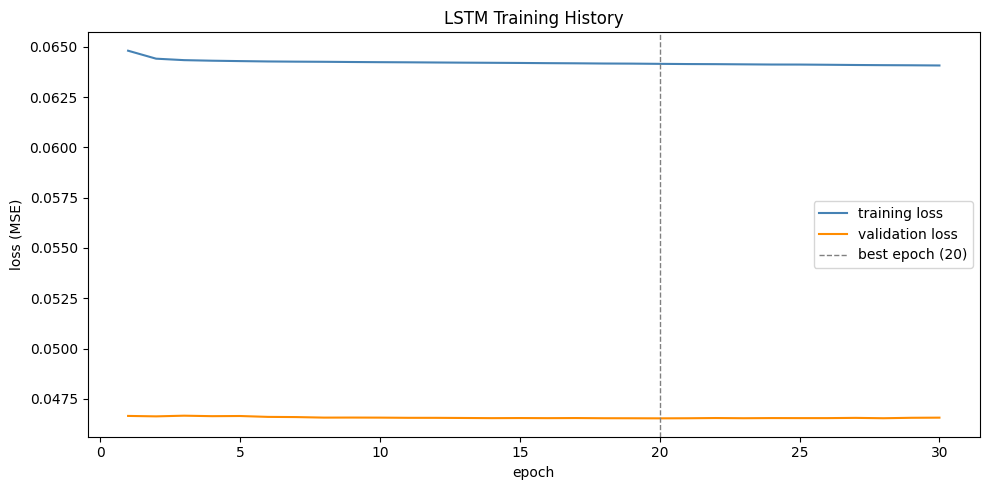

Training history plot saved: training_history_plot.png


In [ ]:
with open(OUTPUT_DIR / 'training_history.json', 'r', encoding='utf-8') as fh:
    hist = json.load(fh)

train_loss = hist['loss']
val_loss   = hist['val_loss']
epochs     = list(range(1, len(train_loss) + 1))
# The best epoch is the one with the lowest validation loss.
best_epoch = int(np.argmin(val_loss)) + 1

# Plot training and validation loss curves with the best epoch marked.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, color='steelblue', linewidth=1.5, label='training loss')
ax.plot(epochs, val_loss,   color='darkorange', linewidth=1.5, label='validation loss')
ax.axvline(x=best_epoch, color='grey', linestyle='--', linewidth=1.0,
           label=f'best epoch ({best_epoch})')
ax.set_title('LSTM Training History')
ax.set_xlabel('epoch')
ax.set_ylabel('loss (MSE)')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'training_history_plot.png'
fig.savefig(str(plot_path), dpi=100)
plt.show()
print(f'Training history plot saved: {plot_path.name}')


## Section 13 — Output File Manifest

Verifies that every expected output file is present.

In [ ]:
# Determine which chart PIDs to include in the manifest.
# If chart_pids is not in memory (e.g. session restarted after Section 11),
# reconstruct the list from the saved product file and series lengths.
_chart_pids_manifest = []
try:
    _chart_pids_manifest = chart_pids
except NameError:
    try:
        with open(OUTPUT_DIR / 'selected_products.json', 'r', encoding='utf-8') as fh:
            _all_pids = json.load(fh)
        _aug_man = pd.read_parquet(PREPROC_DIR / 'daily_counts_augmented.parquet')
        _aug_man['date'] = pd.to_datetime(_aug_man['date'])
        _grp_man = _aug_man.groupby('product_id')
        _lens_man = [
            (p, len(_grp_man.get_group(p)))
            for p in _all_pids if p in _grp_man.groups
        ]
        _lens_man.sort(key=lambda x: x[1], reverse=True)
        _chart_pids_manifest = [p for p, _ in _lens_man[:10]]
    except Exception:
        pass

# List every file the pipeline is expected to produce.
manifest = (
    [
        OUTPUT_DIR / 'selected_products.json',
        OUTPUT_DIR / 'product_window_counts.json',
        OUTPUT_DIR / 'lstm_best.keras',
        OUTPUT_DIR / 'lstm_forecast.keras',
        OUTPUT_DIR / 'baseline_model.joblib',
        OUTPUT_DIR / 'training_history.json',
        OUTPUT_DIR / 'training_history_plot.png',
        OUTPUT_DIR / 'evaluation_results.json',
        OUTPUT_DIR / 'training_checkpoint.json',
    ]
    + [OUTPUT_DIR / 'charts' / f'forecast_{pid}.png' for pid in _chart_pids_manifest]
    + [OUTPUT_DIR / 'charts' / f'shap_{pid}.png'     for pid in _chart_pids_manifest]
)

print('=' * 60)
print('  OUTPUT FILE MANIFEST')
print('=' * 60)
all_present = True
for fpath in manifest:
    status = 'OK' if fpath.exists() else 'MISSING'
    if status == 'MISSING':
        all_present = False
    print(f'  {status:<8}  {fpath.name}')
print()
if all_present:
    print('Task 1B training complete. All artefacts verified.')
else:
    print('Some artefacts are missing. Rerun the relevant sections.')


  OUTPUT FILE MANIFEST
  OK        selected_products.json
  OK        product_window_counts.json
  OK        lstm_best.keras
  OK        lstm_forecast.keras
  OK        baseline_model.joblib
  OK        training_history.json
  OK        training_history_plot.png
  OK        evaluation_results.json
  OK        training_checkpoint.json
  OK        forecast_34.png
  OK        forecast_116.png
  OK        forecast_196.png
  OK        forecast_329.png
  OK        forecast_427.png
  OK        forecast_691.png
  OK        forecast_1158.png
  OK        forecast_1194.png
  OK        forecast_1244.png
  OK        forecast_1408.png
  OK        shap_34.png
  OK        shap_116.png
  OK        shap_196.png
  OK        shap_329.png
  OK        shap_427.png
  OK        shap_691.png
  OK        shap_1158.png
  OK        shap_1194.png
  OK        shap_1244.png
  OK        shap_1408.png

Task 1B training complete. All artefacts verified.


## Section 14 — Export Model Summary for Web Integration

Assembles a `model_summary.json` file containing all architecture parameters, training configuration, artefact paths, and evaluation results needed by the FastAPI serving layer.

In [3]:
# Load evaluation results from disk.
_eval_path = OUTPUT_DIR / 'evaluation_results.json'
_eval = {}
if _eval_path.exists():
    with open(_eval_path, 'r', encoding='utf-8') as fh:
        _eval = json.load(fh)

# Count how many products the model was trained on.
_n_products = 0
_selected_path = OUTPUT_DIR / 'selected_products.json'
if _selected_path.exists():
    with open(_selected_path, 'r', encoding='utf-8') as fh:
        _n_products = len(json.load(fh))

# Assemble all parameters, artefact paths, and metrics for the serving layer.
model_summary = {
    'input_window'       : INPUT_WINDOW,
    'output_horizon'     : OUTPUT_HORIZON,
    'n_features'         : N_FEATURES,
    'stride'             : STRIDE,
    'lstm_units_1'       : LSTM_UNITS_1,
    'lstm_units_2'       : LSTM_UNITS_2,
    'dropout_1'          : DROPOUT_1,
    'dropout_2'          : DROPOUT_2,
    'learning_rate'      : LEARNING_RATE,
    'batch_size'         : BATCH_SIZE,
    'max_epochs'         : MAX_EPOCHS,
    'es_patience'        : ES_PATIENCE,
    'random_seed'        : RANDOM_SEED,
    'n_products_trained' : _n_products,
    'artefacts': {
        'lstm_model'          : 'data/Task 1B/models/lstm_best.keras',
        'scalers'             : 'data/Task 1B/processed/scalers.joblib',
        'qualifying_products' : 'data/Task 1B/processed/qualifying_products.json',
        'seasonal_config'     : 'data/Task 1B/processed/seasonal_config.json',
    },
    'evaluation': _eval,
}

with open(OUTPUT_DIR / 'model_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(model_summary, fh, indent=2)
print('Saved: model_summary.json')

_manifest = [
    OUTPUT_DIR / 'model_summary.json',
    OUTPUT_DIR / 'lstm_best.keras',
    OUTPUT_DIR / 'lstm_forecast.keras',
    OUTPUT_DIR / 'baseline_model.joblib',
    OUTPUT_DIR / 'selected_products.json',
    OUTPUT_DIR / 'evaluation_results.json',
    OUTPUT_DIR / 'training_history.json',
    PREPROC_DIR / 'scalers.joblib',
    PREPROC_DIR / 'qualifying_products.json',
    PREPROC_DIR / 'seasonal_config.json',
]
print('=' * 60)
print('  OUTPUT FILE MANIFEST')
print('=' * 60)
all_present = True
for _fpath in _manifest:
    _status = 'OK' if _fpath.exists() else 'MISSING'
    if _status == 'MISSING':
        all_present = False
    print(f'  {_status:<8}  {_fpath.name}')
print()
if all_present:
    print('All output files present. Ready for FastAPI serving layer.')
else:
    print('WARNING: some output files are missing. Re-run relevant sections.')
print('=' * 60)


Saved: model_summary.json
  OUTPUT FILE MANIFEST
  OK        model_summary.json
  OK        lstm_best.keras
  OK        lstm_forecast.keras
  OK        baseline_model.joblib
  OK        selected_products.json
  OK        evaluation_results.json
  OK        training_history.json
  OK        scalers.joblib
  OK        qualifying_products.json
  OK        seasonal_config.json

All output files present. Ready for FastAPI serving layer.
